In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

# Run this cell only if executing on a remote Colab kernel
if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    repo_dir = "/content/walmart-sales-forecasting"
    repo_url = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git"

    if not os.path.exists(repo_dir):
        subprocess.run(["git", "clone", repo_url, repo_dir], check=True)
    else:
        subprocess.run(["git", "-C", repo_dir, "pull"], check=True)

    # Pin everyone's Colab runtime to the same library versions as the project's requirements.txt
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", os.path.join(repo_dir, "requirements.txt"), "--quiet"],
        check=True,
    )

    os.chdir(os.path.join(repo_dir, "notebooks"))

    if repo_dir not in sys.path:
        sys.path.append(repo_dir)

    # data/raw/ is gitignored, so the clone above has code but not the competition CSVs.
    # Upload train.csv/, test.csv/, features.csv/, stores.csv, sampleSubmission.csv to this
    # folder in your Google Drive first: MyDrive/walmart-sales-forecasting/data/raw
    from google.colab import drive

    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    local_data_dir = Path(repo_dir) / "data" / "raw"

    if not (local_data_dir / "train.csv").exists():
        if not drive_data_dir.exists():
            raise FileNotFoundError(
                f"Expected competition data in Google Drive at {drive_data_dir}. "
                "Upload train.csv/, test.csv/, features.csv/, stores.csv, and "
                "sampleSubmission.csv there, then re-run this cell."
            )
        local_data_dir.mkdir(parents=True, exist_ok=True)
        for item in drive_data_dir.iterdir():
            dest = local_data_dir / item.name
            if dest.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dest)
            else:
                shutil.copy2(item, dest)

# XGBoost - Walmart Store Sales Forecasting

Person A track, first of three deliverables (XGBoost, LightGBM, ARIMA/SARIMA).
This notebook builds the full sklearn `Pipeline` harness - raw `train.csv`/`test.csv`
in, `Weekly_Sales` predictions out - that the LightGBM notebook will reuse.

Reuses `src/preprocessing.py`, `src/features.py`, `src/validation.py`,
`src/evaluation.py` (Phase 2, already implemented) and adds `src/pipeline.py`
(new: `ModelFeatureSelector`, `build_cv_frames`, `run_cv_experiment`).

Experiments logged to MLflow (`XGBoost_Training` experiment, shared DagsHub
tracking server): holiday sample-weighting, MarkDown features, macro features,
a modest hyperparameter search, and an optional recursive-inference comparison.
Final model fit on all of train, wrapped as a Pipeline, submission written to
`submissions/xgboost_submission.csv`.

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBRegressor

from src.evaluation import weighted_mae
from src.features import WalmartFeatureEngineer, add_temporal_features
from src.pipeline import MACRO_COLS, ModelFeatureSelector, build_cv_frames, run_cv_experiment
from src.preprocessing import MARKDOWN_COLS, WalmartPreprocessor, load_raw_data
from src.validation import describe_split, expanding_window_splits, split_frame

pd.set_option("display.max_columns", None)
DATA_DIR = Path.cwd().parent / "data" / "raw"
FIXED_CATEGORIES = {"Type": ["A", "B", "C"]}

## MLflow setup

Logs to the shared DagsHub MLflow server so runs are comparable across both
tracks (Person A and Person B). Credentials never get typed into the
notebook itself: locally from a `.env` file in the repo root (gitignored);
on Colab from **Colab Secrets** (the key icon in the left sidebar) - each
teammate adds their own `DAGSHUB_USERNAME`/`DAGSHUB_TOKEN` secret once,
tied to their own Google account, never stored in the notebook or the repo.
If authentication fails, the setup cell below raises and stops rather than
silently falling back to a local `./mlruns` store, which would desync this
notebook's runs from the rest of the team's.

###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).

In [ ]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token

In [ ]:
def _load_env_file(path):
    """Minimal .env loader (KEY=VALUE per line) - avoids adding python-dotenv
    as a dependency for a two-line credentials file. Uses setdefault so an
    env var already set in the shell (local dev) is never overridden."""
    path = Path(path)
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        os.environ.setdefault(key.strip(), value.strip())


if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided by the manual-override cell above (e.g. driving a Colab
    # runtime from VS Code, where google.colab.userdata would time out). Do NOT
    # evaluate userdata.get(...) in that case - it blocks and then raises.
    pass
elif "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    # Colab Secrets (key icon, left sidebar) - each teammate adds their own
    # DAGSHUB_USERNAME/DAGSHUB_TOKEN secret, tied to their own Google account.
    # Never stored in the notebook or repo, unlike a hardcoded token would be.
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
else:
    _load_env_file(Path.cwd().parent / ".env")

In [3]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("XGBoost_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns - that would desync from Person B's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("XGBoost_Training").name)

MLflow tracking URI: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow


Active experiment: XGBoost_Training


## Load raw data

In [4]:
raw = load_raw_data(DATA_DIR)
for name, df in raw.items():
    print(f"{name}: {df.shape}")

assert raw["train"].shape[0] == 421_570, "unexpected train row count - check data/raw"
assert raw["test"].shape[0] > 0
assert raw["stores"].shape[0] == 45

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


## Preprocessing + temporal features (global, stateless, safe to run once)

`WalmartPreprocessor` (merge with `features`/`stores`, dtype cleanup) and
`add_temporal_features` (calendar/holiday-distance columns) don't depend on
`Weekly_Sales` in any way - they're safe to run once on the full train set
and reuse across every CV fold below. `WalmartFeatureEngineer` (lag/rolling/
store-dept aggregates) is different - it must be refit per fold, see below.

In [5]:
preprocessor = WalmartPreprocessor(data_dir=DATA_DIR).fit(raw["train"])
train_feat = add_temporal_features(preprocessor.transform(raw["train"]))
print(train_feat.shape)
train_feat.head(3)

(421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,7,217,294,329
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,0,210,287,322
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,-7,203,280,315


## Time-based CV: expanding-window splits

Three expanding-window folds, 13-week validation windows, computed once and
reused across every experiment below so WMAE numbers are directly comparable.

**Known limitations of this CV setup** (documented, not "fixed" - modifying
the shared `src/validation.py` splitter would break comparability with the
other 6 models' tracks):

- Train ends 2012-11-01, so no fold's validation window can ever contain a
  Thanksgiving or Christmas week - those only appear in the real `test.csv`
  period. WMAE weights holiday weeks 5x, and Thanksgiving/Christmas are the
  two biggest sales-driving holidays of the year, so CV WMAE is blind to
  exactly the highest-stakes part of the real scoring metric.
- Validation windows are 13 weeks; the real test horizon is 39 weeks. By the
  back half of test, `sales_lag_1/4/13/26` are all NaN and only
  `sales_lag_52` + store/dept means remain - CV never exercises that
  late-horizon regime as thoroughly as the actual submission will.

In [6]:
splits = expanding_window_splits(train_feat["Date"], n_splits=3, val_weeks=13)
assert len(splits) == 3, "history too short for 3 folds - check min_train_weeks"

for i, split in enumerate(splits):
    print(f"fold {i}:", describe_split(split))

fold 0: {'train_start': 'start_of_history', 'train_end': '2012-01-27 00:00:00', 'val_start': '2012-02-03 00:00:00', 'val_end': '2012-04-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}
fold 1: {'train_start': 'start_of_history', 'train_end': '2012-04-27 00:00:00', 'val_start': '2012-05-04 00:00:00', 'val_end': '2012-07-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 0}
fold 2: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}


## Build the CV frame cache (expensive step, run once)

`WalmartFeatureEngineer.fit()` builds a Date x (Store, Dept) pivot table over
up to ~380k rows - fitting it fresh per experiment per fold would be wasteful
and slow. `build_cv_frames` fits it once per fold (3 total, each on that
fold's train-only rows to avoid leaking validation-period aggregates) and
caches the fully-featurized train/val frames. Every experiment below reuses
this cache - only column selection, `sample_weight`, and model hyperparameters
vary between runs.

In [7]:
FEATURE_ENGINEER_KWARGS = {"lag_weeks": [1, 4, 13, 26, 52], "rolling_weeks": [4, 13, 52]}

cv_frames = build_cv_frames(train_feat, splits, feature_engineer_kwargs=FEATURE_ENGINEER_KWARGS)
for i, f in enumerate(cv_frames):
    print(f"fold {i}: train={f['train'].shape}, val={f['val'].shape}")

fold 0: train=(305982, 37), val=(38685, 37)
fold 1: train=(344667, 37), val=(38373, 37)
fold 2: train=(383040, 37), val=(38530, 37)


## Zero/negative `Weekly_Sales` decision

A small fraction of rows have `Weekly_Sales` <= 0 (returns / inactive
departments). Decision: **keep them.** Tree models split around outliers
fine, and dropping/clipping would throw away real signal about the sparse
end of the sales distribution. Logged as an explicit param
(`keep_nonpositive_sales`) on every run below rather than silently assumed.

In [8]:
nonpositive_frac = (train_feat["Weekly_Sales"] <= 0).mean()
print(f"rows with Weekly_Sales <= 0: {nonpositive_frac:.3%}")

KEEP_NONPOSITIVE_SALES = True

rows with Weekly_Sales <= 0: 0.322%


## Pipeline smoke test

Validates the full `Pipeline` (`WalmartPreprocessor` -> `add_temporal_features`
-> `WalmartFeatureEngineer` -> `ModelFeatureSelector` -> `XGBRegressor` with
`enable_categorical=True`) and `model__sample_weight` routing work end-to-end,
on a cheap slice, before committing to the full experiment sequence.

In [9]:
smoke_cutoff = train_feat["Date"].sort_values().unique()[60]
smoke_train = raw["train"][raw["train"]["Date"] <= smoke_cutoff]
smoke_test = raw["test"][raw["test"]["Date"] <= raw["test"]["Date"].min() + pd.Timedelta(weeks=2)]

smoke_pipeline = Pipeline(
    [
        ("preprocess", WalmartPreprocessor(data_dir=DATA_DIR)),
        ("temporal", FunctionTransformer(add_temporal_features, validate=False)),
        ("features", WalmartFeatureEngineer(**FEATURE_ENGINEER_KWARGS)),
        ("select", ModelFeatureSelector(fixed_categories=FIXED_CATEGORIES)),
        ("model", XGBRegressor(n_estimators=50, max_depth=4, enable_categorical=True, tree_method="hist", random_state=42)),
    ]
)

smoke_weights = np.where(smoke_train["IsHoliday"].values, 5.0, 1.0)
smoke_pipeline.fit(smoke_train, smoke_train["Weekly_Sales"], model__sample_weight=smoke_weights)
smoke_preds = smoke_pipeline.predict(smoke_test)

print("smoke test predictions:", smoke_preds[:5])
assert not np.isnan(smoke_preds).any(), "pipeline produced NaN predictions on raw test-shaped input"
print("Pipeline smoke test passed.")

smoke test predictions: [19517.223 19517.223 19517.223 45622.094 45622.094]
Pipeline smoke test passed.


## MLflow run helper

Every experiment below follows the same shape: build an `XGBRegressor` with
some config, score it against the cached `cv_frames` via `run_cv_experiment`,
and log params/metrics/artifacts as one MLflow run. This helper keeps that
consistent without repeating the logging boilerplate ~9 times.

In [10]:
def log_cv_run(run_name, model_kwargs, experiment_group, drop_cols=None,
               sample_weight_fn=None, extra_params=None, holiday_weight=None):
    """Fit+score an XGBRegressor(**model_kwargs) against cv_frames, log one MLflow run."""
    model = XGBRegressor(
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
        **model_kwargs,
    )
    result = run_cv_experiment(
        model,
        cv_frames,
        drop_cols=drop_cols,
        fixed_categories=FIXED_CATEGORIES,
        sample_weight_fn=sample_weight_fn,
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("experiment_group", experiment_group)
        mlflow.log_params(model_kwargs)
        mlflow.log_param("drop_cols", drop_cols or [])
        mlflow.log_param("sample_weight", sample_weight_fn is not None)
        if holiday_weight is not None:
            mlflow.log_param("holiday_weight", holiday_weight)
        mlflow.log_param("keep_nonpositive_sales", KEEP_NONPOSITIVE_SALES)
        mlflow.log_param("cv_strategy", "expanding_window")
        mlflow.log_param("n_splits", len(splits))
        mlflow.log_param("val_weeks", 13)
        mlflow.log_param("min_train_weeks", 52)
        mlflow.log_param("lag_weeks", FEATURE_ENGINEER_KWARGS["lag_weeks"])
        mlflow.log_param("rolling_weeks", FEATURE_ENGINEER_KWARGS["rolling_weeks"])
        if extra_params:
            mlflow.log_params(extra_params)

        for i, fr in enumerate(result["fold_results"]):
            mlflow.log_metric(f"wmae_fold_{i}", fr["wmae"])
            mlflow.log_metric(f"mae_fold_{i}", fr["mae"])
        mlflow.log_metric("wmae_mean", result["wmae_mean"])
        mlflow.log_metric("wmae_std", result["wmae_std"])
        mlflow.log_metric("mae_mean", result["mae_mean"])

        mlflow.log_dict({"fold_results": result["fold_results"]}, "cv_results.json")

    print(f"{run_name}: wmae_mean={result['wmae_mean']:.2f} (+/- {result['wmae_std']:.2f})")
    return result

## Experiment 1: holiday sample weighting

WMAE weights holiday weeks 5x. Compares `sample_weight = where(IsHoliday, 5, 1)`
in `.fit()` against unweighted training, holding everything else (features,
hyperparameters) at a fixed baseline.

In [11]:
BASELINE_HP = {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.1, "subsample": 0.8}

result_unweighted = log_cv_run(
    "XGBoost_CV_HolidayWeight_Off", BASELINE_HP, experiment_group="holiday_weight",
)
result_weighted = log_cv_run(
    "XGBoost_CV_HolidayWeight_On", BASELINE_HP, experiment_group="holiday_weight",
    sample_weight_fn=lambda df: np.where(df["IsHoliday"].values, 5.0, 1.0),
    holiday_weight=5.0,
)

BEST_SAMPLE_WEIGHT = result_weighted["wmae_mean"] <= result_unweighted["wmae_mean"]
print("BEST_SAMPLE_WEIGHT =", BEST_SAMPLE_WEIGHT)

🏃 View run XGBoost_CV_HolidayWeight_Off at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/60b9c6adb1c143788d5388cd246bc95a
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HolidayWeight_Off: wmae_mean=3067.38 (+/- 305.75)


🏃 View run XGBoost_CV_HolidayWeight_On at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/e21dd30dacca4bada1337b6b4330be45
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HolidayWeight_On: wmae_mean=2852.32 (+/- 121.70)
BEST_SAMPLE_WEIGHT = True


In [12]:
def best_sample_weight_fn():
    return (lambda df: np.where(df["IsHoliday"].values, 5.0, 1.0)) if BEST_SAMPLE_WEIGHT else None

## Experiment 2: MarkDown features

MarkDown1-5 are all-null before 2011-11-11. Compares dropping them entirely
against keeping them (filled with 0 by `WalmartPreprocessor.clean()`), using
the winning holiday-weighting choice from Experiment 1. The "keep" arm is
already logged as part of Experiment 1's winning run - only the "drop" arm
needs a new run here.

In [13]:
result_no_markdown = log_cv_run(
    "XGBoost_CV_MarkDown_Off", BASELINE_HP, experiment_group="markdown",
    drop_cols=MARKDOWN_COLS,
    sample_weight_fn=best_sample_weight_fn(),
    holiday_weight=5.0 if BEST_SAMPLE_WEIGHT else None,
)

baseline_wmae = result_weighted["wmae_mean"] if BEST_SAMPLE_WEIGHT else result_unweighted["wmae_mean"]
BEST_DROP_MARKDOWN = result_no_markdown["wmae_mean"] < baseline_wmae
print("BEST_DROP_MARKDOWN =", BEST_DROP_MARKDOWN, f"(with={baseline_wmae:.2f}, without={result_no_markdown['wmae_mean']:.2f})")

🏃 View run XGBoost_CV_MarkDown_Off at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/21ec815bb642470488567e051c930ded
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_MarkDown_Off: wmae_mean=2952.46 (+/- 57.01)
BEST_DROP_MARKDOWN = False (with=2852.32, without=2952.46)


## Experiment 3: macro features

Compares dropping CPI/Unemployment/Fuel_Price/Temperature against keeping
them, carrying forward the best holiday-weighting and MarkDown choices.

In [14]:
carried_drop_cols = list(MARKDOWN_COLS) if BEST_DROP_MARKDOWN else []

result_no_macro = log_cv_run(
    "XGBoost_CV_Macro_Off", BASELINE_HP, experiment_group="macro",
    drop_cols=carried_drop_cols + MACRO_COLS,
    sample_weight_fn=best_sample_weight_fn(),
    holiday_weight=5.0 if BEST_SAMPLE_WEIGHT else None,
)

macro_baseline_wmae = result_no_markdown["wmae_mean"] if BEST_DROP_MARKDOWN else baseline_wmae
BEST_DROP_MACRO = result_no_macro["wmae_mean"] < macro_baseline_wmae
print("BEST_DROP_MACRO =", BEST_DROP_MACRO, f"(with={macro_baseline_wmae:.2f}, without={result_no_macro['wmae_mean']:.2f})")

BEST_DROP_COLS = carried_drop_cols + (MACRO_COLS if BEST_DROP_MACRO else [])
print("BEST_DROP_COLS =", BEST_DROP_COLS)

🏃 View run XGBoost_CV_Macro_Off at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/0a1295c4dc224657818a5ce582194c64
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_Macro_Off: wmae_mean=3028.23 (+/- 460.97)
BEST_DROP_MACRO = False (with=2852.32, without=3028.23)
BEST_DROP_COLS = []


## Experiment 4: modest hyperparameter search

Four hand-picked `(max_depth, n_estimators, learning_rate, subsample)`
combinations against the carried-forward feature/weighting config - a small,
deliberate set rather than a full grid, scored with the same shared CV
splitter (never sklearn's random-split CV, which would leak future data).

In [15]:
HP_GRID = [
    {"max_depth": 4, "n_estimators": 800, "learning_rate": 0.03, "subsample": 0.8},
    {"max_depth": 6, "n_estimators": 300, "learning_rate": 0.1, "subsample": 0.6},
    {"max_depth": 6, "n_estimators": 600, "learning_rate": 0.05, "subsample": 1.0},
    {"max_depth": 8, "n_estimators": 500, "learning_rate": 0.03, "subsample": 0.8},
]

hp_results = []
for i, hp in enumerate(HP_GRID, start=1):
    result = log_cv_run(
        f"XGBoost_CV_HP_{i}", hp, experiment_group="hyperparam",
        drop_cols=BEST_DROP_COLS,
        sample_weight_fn=best_sample_weight_fn(),
        holiday_weight=5.0 if BEST_SAMPLE_WEIGHT else None,
    )
    hp_results.append((hp, result["wmae_mean"]))

hp_baseline_wmae = macro_baseline_wmae
best_hp, best_hp_wmae = min(hp_results, key=lambda t: t[1])
if best_hp_wmae < hp_baseline_wmae:
    BEST_HYPERPARAMS = best_hp
else:
    BEST_HYPERPARAMS = BASELINE_HP
print("BEST_HYPERPARAMS =", BEST_HYPERPARAMS, f"(wmae={min(best_hp_wmae, hp_baseline_wmae):.2f})")

🏃 View run XGBoost_CV_HP_1 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/726e8d9ddb49445ebdadce13200c87b0
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HP_1: wmae_mean=3591.63 (+/- 320.03)


🏃 View run XGBoost_CV_HP_2 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/ae4698c00f3e489a9e61a6e8bf1382cc
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HP_2: wmae_mean=3133.41 (+/- 389.73)


🏃 View run XGBoost_CV_HP_3 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/52466d450f0a446baf5e7770e814d9b6
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HP_3: wmae_mean=3178.36 (+/- 527.56)


🏃 View run XGBoost_CV_HP_4 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/408dd25a43594975a5599ce1d7f37ca9
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


XGBoost_CV_HP_4: wmae_mean=2587.20 (+/- 162.97)
BEST_HYPERPARAMS = {'max_depth': 8, 'n_estimators': 500, 'learning_rate': 0.03, 'subsample': 0.8} (wmae=2587.20)


## Experiment 5 (optional/stretch): recursive week-by-week inference

Native XGBoost NaN routing (used everywhere above) relies on `sales_lag_52`
and the store/dept mean aggregates once `sales_lag_1/4/13/26` go NaN past the
fit history. The alternative is recursive inference: predict one week, feed
that prediction back into `WalmartFeatureEngineer.update_history()`, then
predict the next week with real (if noisy) short-horizon lags. This is
compared here on the last (most test-like) fold only - it's the optional
stretch experiment from the task spec, not part of the main greedy sequence
above, and its result does not change `BEST_HYPERPARAMS`/`BEST_DROP_COLS`.

In [16]:
last_split = cv_frames[-1]["split"]
last_fold = cv_frames[-1]
fe_last = last_fold["feature_engineer"]

# Pre-FeatureEngineer val frame (post preprocess + temporal only) - re-transformed
# week by week below so each week's lag/rolling features reflect the recursively
# updated history, instead of the static one-shot transform cached in cv_frames.
_, fold_val_raw = split_frame(train_feat, last_split)
val_dates = sorted(fold_val_raw["Date"].unique())

recursive_model = XGBRegressor(
    enable_categorical=True, tree_method="hist", random_state=42, **BEST_HYPERPARAMS,
)
selector = ModelFeatureSelector(drop_cols=BEST_DROP_COLS, fixed_categories=FIXED_CATEGORIES)
X_train_last = selector.fit_transform(last_fold["train"])
y_train_last = last_fold["train"]["Weekly_Sales"]
fit_kwargs = {}
if BEST_SAMPLE_WEIGHT:
    fit_kwargs["sample_weight"] = np.where(last_fold["train"]["IsHoliday"].values, 5.0, 1.0)
recursive_model.fit(X_train_last, y_train_last, **fit_kwargs)

recursive_preds = []
recursive_actuals = []
recursive_holiday = []
for d in val_dates:
    week_raw = fold_val_raw[fold_val_raw["Date"] == d]
    week_feat = fe_last.transform(week_raw)
    X_week = selector.transform(week_feat)
    preds = recursive_model.predict(X_week)
    recursive_preds.extend(preds)
    recursive_actuals.extend(week_raw["Weekly_Sales"].values)
    recursive_holiday.extend(week_raw["IsHoliday"].values)
    # feed this week's predictions back into history for next week's lag/rolling lookups
    fe_last.update_history(pd.DataFrame({
        "Store": week_raw["Store"].values,
        "Dept": week_raw["Dept"].values,
        "Date": week_raw["Date"].values,
        "Weekly_Sales": preds,
    }))

wmae_recursive = weighted_mae(np.array(recursive_actuals), np.array(recursive_preds), np.array(recursive_holiday))

with mlflow.start_run(run_name="XGBoost_CV_RecursiveInference"):
    mlflow.set_tag("experiment_group", "recursive_inference")
    mlflow.log_params(BEST_HYPERPARAMS)
    mlflow.log_param("drop_cols", BEST_DROP_COLS)
    mlflow.log_param("fold", "last")
    mlflow.log_param("nan_lag_strategy", "recursive")
    mlflow.log_metric("wmae_recursive_last_fold", wmae_recursive)

print(f"Recursive inference WMAE on last fold: {wmae_recursive:.2f}")
print("(Compare against the last-fold native-NaN WMAE logged under XGBoost_CV_HP_* / the winning HP run above.)")

🏃 View run XGBoost_CV_RecursiveInference at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/dbc499f3797b48b6b563b7e4a9349f4c
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


Recursive inference WMAE on last fold: 1514.66
(Compare against the last-fold native-NaN WMAE logged under XGBoost_CV_HP_* / the winning HP run above.)


## Key finding: far-horizon feature availability (why the final model differs from CV)

The CV experiments above use the full lag/rolling feature set
(`lag_weeks=[1,4,13,26,52]`, `rolling_weeks=[4,13,52]`) and picked a best CV
WMAE around 2587. But that number is **optimistic**, and the first Kaggle
submission built this way scored far worse (Public 5101 / Private 5279).

The reason is a train/test feature-availability mismatch that CV structurally
cannot see. `WalmartFeatureEngineer` looks lag/rolling values up from a history
snapshot frozen at train's end. Test spans ~39 weeks past that end, so:

| feature | NaN rate across test |
|---|---|
| `sales_lag_1` | 95% (100% from test-week 2 onward) |
| `sales_lag_4` | 87% |
| `sales_lag_13` | 65% |
| `sales_lag_26` | 32% |
| all 6 rolling features | ~95% |
| **`sales_lag_52`** | **1.8%** (always reaches back into train) |

During training these short lags are almost always present, so the model learns
to lean on them; at test time they vanish and route to XGBoost's NaN-default
direction (tuned on the few early-2010 rows where those lags were also NaN), and
predictions collapse. CV never caught it because the 13-week validation windows
still have the short lags partly alive - only real test runs far enough out for
`sales_lag_52` to be the sole surviving lag.

**Fix:** the final/submission pipeline trains on only the features that are
actually available at the full test horizon - `sales_lag_52`, the store/dept
mean aggregates, calendar, and external features - by dropping the short lags
and all rolling windows (`lag_weeks=[52], rolling_weeks=[]`). This forces the
model onto `store_dept_mean_sales` + `sales_lag_52` (both always present) instead
of features that evaporate. On Kaggle this took the submission from Public 5101 /
Private 5279 down to **Public 2858 / Private 3027** (-44% / -43%), and brought
the score in line with the CV estimate - i.e. CV became honest once train and
test used the same available features.

The full recursive-inference alternative (keep short lags real via
`update_history()` week by week) is documented above as the stretch experiment;
this horizon-safe feature choice gets most of the benefit for a one-line change.

## Final fit

Assembles the real `Pipeline` and fits it on **all** of `raw["train"]` (raw,
unprocessed - the Pipeline handles preprocessing/feature engineering
internally). It carries forward the winning holiday-weighting, MarkDown/macro,
and hyperparameter choices from CV, but swaps the feature engineer to the
horizon-safe set (`FINAL_FEATURE_ENGINEER_KWARGS`, see the finding above) so the
submission does not depend on lag/rolling features that are NaN across most of
test. Logged as `XGBoost_Final` with a feature importance plot.

In [17]:
# Final model uses ONLY test-horizon-available features (see the finding above),
# unlike the CV experiments which explored the full lag/rolling set.
FINAL_FEATURE_ENGINEER_KWARGS = {"lag_weeks": [52], "rolling_weeks": []}

final_pipeline = Pipeline(
    [
        ("preprocess", WalmartPreprocessor(data_dir=DATA_DIR)),
        ("temporal", FunctionTransformer(add_temporal_features, validate=False)),
        ("features", WalmartFeatureEngineer(**FINAL_FEATURE_ENGINEER_KWARGS)),
        ("select", ModelFeatureSelector(drop_cols=BEST_DROP_COLS, fixed_categories=FIXED_CATEGORIES)),
        (
            "model",
            XGBRegressor(
                enable_categorical=True, tree_method="hist", random_state=42, **BEST_HYPERPARAMS,
            ),
        ),
    ]
)

final_fit_kwargs = {}
if BEST_SAMPLE_WEIGHT:
    final_fit_kwargs["model__sample_weight"] = np.where(raw["train"]["IsHoliday"].values, 5.0, 1.0)

final_pipeline.fit(raw["train"], raw["train"]["Weekly_Sales"], **final_fit_kwargs)
print("Final pipeline fit on", raw["train"].shape[0], "rows.")
print("Final feature engineer config (horizon-safe):", FINAL_FEATURE_ENGINEER_KWARGS)

Final pipeline fit on 421570 rows.
Final feature engineer config (horizon-safe): {'lag_weeks': [52], 'rolling_weeks': []}


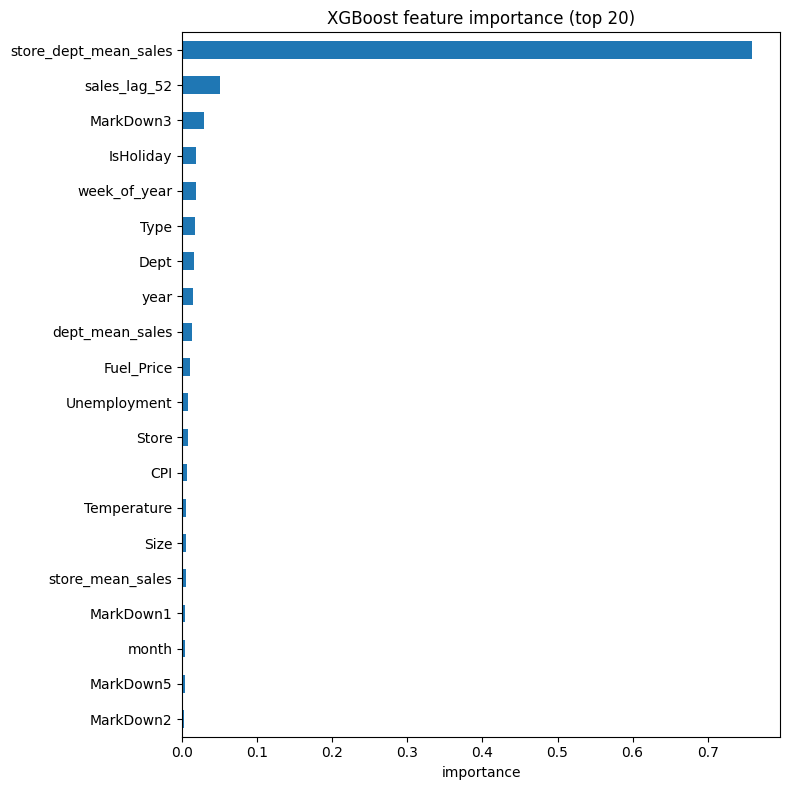

In [18]:
booster = final_pipeline.named_steps["model"]
importances = pd.Series(booster.feature_importances_, index=booster.feature_names_in_).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(20).iloc[::-1].plot.barh(ax=ax)
ax.set_title("XGBoost feature importance (top 20)")
ax.set_xlabel("importance")
plt.tight_layout()
FEATURE_IMPORTANCE_PATH = Path.cwd().parent / "submissions" / "_xgboost_feature_importance.png"
fig.savefig(FEATURE_IMPORTANCE_PATH)
plt.show()

In [19]:
train_preds = final_pipeline.predict(raw["train"])
wmae_train = weighted_mae(raw["train"]["Weekly_Sales"].values, train_preds, raw["train"]["IsHoliday"].values)
mae_train = float(np.mean(np.abs(raw["train"]["Weekly_Sales"].values - train_preds)))

with mlflow.start_run(run_name="XGBoost_Final") as final_run:
    mlflow.set_tag("experiment_group", "final")
    mlflow.log_params(BEST_HYPERPARAMS)
    mlflow.log_param("drop_cols", BEST_DROP_COLS)
    mlflow.log_param("sample_weight", BEST_SAMPLE_WEIGHT)
    mlflow.log_param("holiday_weight", 5.0 if BEST_SAMPLE_WEIGHT else None)
    mlflow.log_param("keep_nonpositive_sales", KEEP_NONPOSITIVE_SALES)
    mlflow.log_param("enable_categorical", True)
    mlflow.log_param("tree_method", "hist")
    mlflow.log_param("nan_lag_strategy", "horizon_safe_lag52")
    mlflow.log_param("feature_set", "test_horizon_safe")
    mlflow.log_param("cv_strategy", "expanding_window")
    mlflow.log_param("n_splits", len(splits))
    mlflow.log_param("val_weeks", 13)
    mlflow.log_param("lag_weeks", FINAL_FEATURE_ENGINEER_KWARGS["lag_weeks"])
    mlflow.log_param("rolling_weeks", FINAL_FEATURE_ENGINEER_KWARGS["rolling_weeks"])
    mlflow.log_param("cv_lag_weeks", FEATURE_ENGINEER_KWARGS["lag_weeks"])
    mlflow.log_param("cv_rolling_weeks", FEATURE_ENGINEER_KWARGS["rolling_weeks"])

    # in-sample metrics only (optimistic) - the trustworthy estimate is the CV wmae from
    # the winning experiment runs above, carried here for reference
    mlflow.log_metric("wmae_train", wmae_train)
    mlflow.log_metric("mae_train", mae_train)
    mlflow.log_metric("wmae_cv_mean_at_selection", min(hp_baseline_wmae, best_hp_wmae))

    mlflow.log_artifact(str(FEATURE_IMPORTANCE_PATH))
    mlflow.sklearn.log_model(final_pipeline, "model", input_example=raw["test"].head(5))

    final_run_id = final_run.info.run_id

print("wmae_train (in-sample, optimistic):", wmae_train)
print("Logged as XGBoost_Final, run_id:", final_run_id)

2026/07/10 00:41:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/10 00:41:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run XGBoost_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/f850d3b1750d466e84b79b8651b0d950
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


wmae_train (in-sample, optimistic): 1438.2065638887925
Logged as XGBoost_Final, run_id: f850d3b1750d466e84b79b8651b0d950


## Submission

Runs the fitted pipeline directly on raw `test.csv`-shaped data (no manual
preprocessing needed) and writes `submissions/xgboost_submission.csv`.

In [20]:
test_preds = final_pipeline.predict(raw["test"])
assert not np.isnan(test_preds).any(), "final pipeline produced NaN predictions on raw test data"

submission = pd.DataFrame(
    {
        "Id": (
            raw["test"]["Store"].astype(str)
            + "_"
            + raw["test"]["Dept"].astype(str)
            + "_"
            + raw["test"]["Date"].dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_preds,
    }
)

SUBMISSION_PATH = Path.cwd().parent / "submissions" / "xgboost_submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print("Wrote", SUBMISSION_PATH, submission.shape)
submission.head()

Wrote C:\Users\User\OneDrive\Desktop\ML_final\walmart-sales-forecasting\submissions\xgboost_submission.csv (115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,42701.050781
1,1_1_2012-11-09,19856.880859
2,1_1_2012-11-16,20728.238281
3,1_1_2012-11-23,24042.701172
4,1_1_2012-11-30,26960.808594


In [21]:
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact(str(SUBMISSION_PATH))

print("Submission logged as an artifact on XGBoost_Final (run_id:", final_run_id, ")")

🏃 View run XGBoost_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0/runs/f850d3b1750d466e84b79b8651b0d950
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/0


Submission logged as an artifact on XGBoost_Final (run_id: f850d3b1750d466e84b79b8651b0d950 )
